<a href="https://colab.research.google.com/github/dindahanifa/mechine_learning/blob/main/Prediksi_Churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn import tree

Fungsi: memanggil library yang digunakan untuk analisis data, visualisasi, dan pemodelan machine learning.

2. Load Dataset

In [3]:
df = pd.read_csv('churn.csv')
df.head()

,usia,lama_langganan_bulan,jumlah_pengaduan,paket_internet,metode_pembayaran,churn
0,58,4,4,Standard,Transfer,Ya
1,25,16,0,Premium,Kartu Kredit,Tidak
2,19,57,4,Standard,Transfer,Ya
3,65,37,0,Premium,Transfer,Tidak
4,35,6,3,Basic,Transfer,Tidak


Fungsi: membaca dataset churn.csv dan menampilkan 5 baris pertama.


3. Eksplorasi Data


/tmp/ipython-input-473544409.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='churn', data=df, palette='coolwarm')


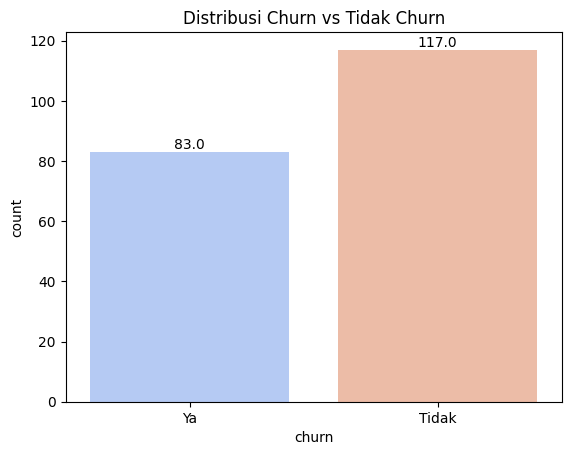

In [28]:
sns.countplot(x='churn', data=df, palette='coolwarm')
plt.title('Distribusi Churn vs Tidak Churn')

# Add annotations to the bars
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                       ha='center', va='center', xytext=(0, 5), textcoords='offset points')

plt.show()

Tujuan:
Mengetahui struktur data dan tipe data setiap kolom.
Melihat distribusi jumlah pelanggan yang churn dan tidak churn.

4. Pra-Pemrosesan Data

In [5]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,usia,lama_langganan_bulan,jumlah_pengaduan,paket_internet_Premium,paket_internet_Standard,metode_pembayaran_Transfer,metode_pembayaran_e-Wallet,churn_Ya
0,58,4,4,False,True,True,False,True
1,25,16,0,True,False,False,False,False
2,19,57,4,False,True,True,False,True
3,65,37,0,True,False,True,False,False
4,35,6,3,False,False,True,False,False


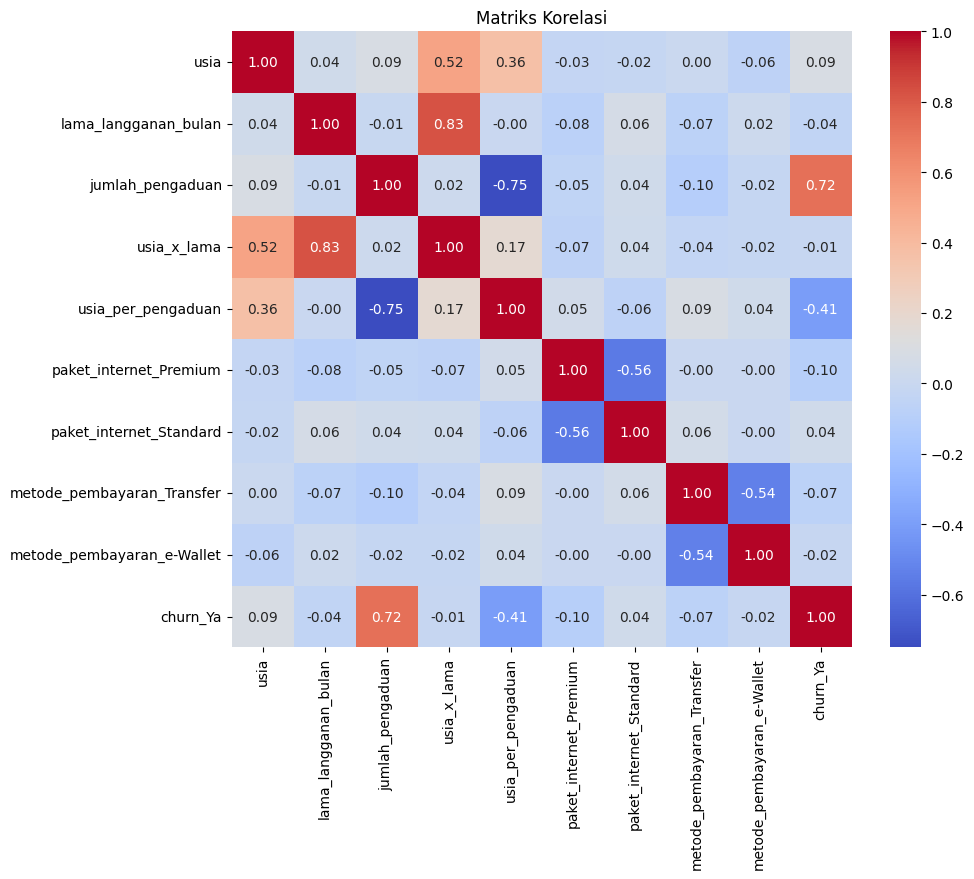

In [29]:
correlation_matrix = df_encoded.corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriks Korelasi')
plt.show()

Fungsi: mengubah kolom kategorikal menjadi bentuk numerik (boolean) dengan One-Hot Encoding.

5. Split Data Training dan Testing

In [6]:
X = df_encoded.drop('churn_Ya', axis=1)
y = df_encoded['churn_Ya']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print('Ukuran data train:', X_train.shape)
print('Ukuran data test:', X_test.shape)

Ukuran data train: (160, 7)
Ukuran data test: (40, 7)


Tujuan: membagi data menjadi:
80% untuk pelatihan (training)
20% untuk pengujian (testing)


6. Membangun Model Decision Tree

In [7]:
model = DecisionTreeClassifier(criterion='gini', max_depth=5, random_state=42)
model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

Fungsi: membuat dan melatih model pohon keputusan berdasarkan data training.

7. Prediksi dan Evaluasi Model

In [8]:
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print('Akurasi Model: ', acc)
print('Confusion Matrix: ', cm)
print('Classification Report: ', classification_report(y_test, y_pred))

Akurasi Model:  0.9
Confusion Matrix:  [[27  1]
 [ 3  9]]
Classification Report:                precision    recall  f1-score   support

       False       0.90      0.96      0.93        28
        True       0.90      0.75      0.82        12

    accuracy                           0.90        40
   macro avg       0.90      0.86      0.87        40
weighted avg       0.90      0.90      0.90        40



Tujuan: mengukur seberapa baik model memprediksi data baru.


8. Visualisasi Confusion Matrix


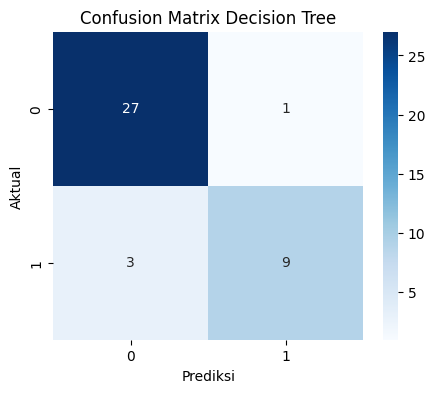

In [9]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Decision Tree')
plt.show()

Fungsi: menampilkan performa model secara visual antara nilai aktual dan prediksi.

9. Visualisasi Pohon Keputusan


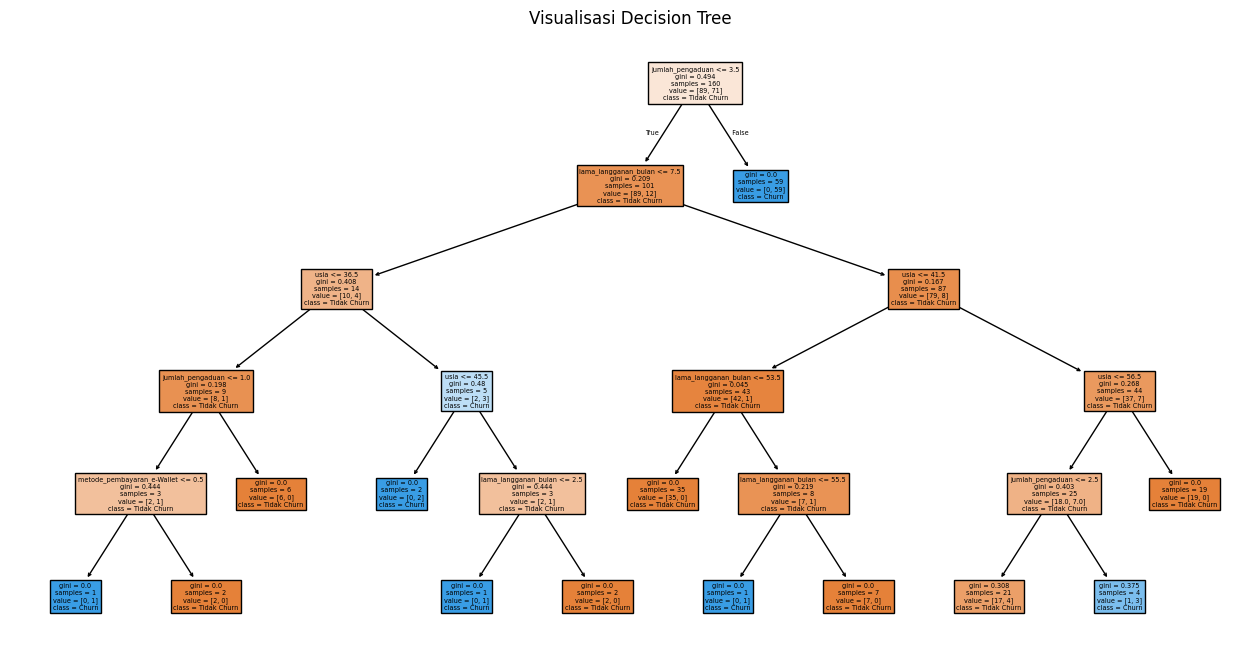

In [10]:
plt.figure(figsize=(16,8))
tree.plot_tree(model, feature_names=X.columns, class_names=['Tidak Churn','Churn'], filled=True)
plt.title('Visualisasi Decision Tree')
plt.show()

Fungsi: menampilkan struktur pohon untuk memahami bagaimana model mengambil keputusan.


10. Kesimpulan
Model Decision Tree dapat digunakan untuk memprediksi churn pelanggan.
Akurasi model menunjukkan seberapa baik prediksi terhadap data test.
Struktur pohon membantu memahami pola faktor yang menyebabkan churn.
Untuk hasil yang lebih baik, model dapat dikembangkan menggunakan Random Forest atau Gradient Boosting.


**Tugas / Pertanyaan**

**1. Jelaskan apa perbedaan antara training data dan testing data!**

**Data Training:**
* Digunakan untuk melatih model. Model "belajar" dari pola dan hubungan dalam data training untuk membuat prediksi.
* Ini adalah bagian terbesar dari dataset.

**Data Testing:**
* Digunakan untuk mengevaluasi performa model setelah dilatih. Model membuat prediksi pada data testing, dan hasilnya dibandingkan dengan nilai aktual untuk mengukur akurasi dan metrik lainnya.
* Data testing harus belum pernah dilihat oleh model selama pelatihan untuk memberikan gambaran yang objektif tentang seberapa baik model akan bekerja pada data baru yang tidak terlihat.

**Tujuan:**

Membagi data menjadi training dan testing sangat penting untuk menghindari *overfitting*, yaitu ketika model berkinerja sangat baik pada data training tetapi buruk pada data baru. Dengan mengevaluasi model pada data testing yang terpisah, kita dapat mendapatkan perkiraan yang lebih realistis tentang bagaimana model akan berkinerja di dunia nyata.

**2. Apa fungsi parameter criterion='gini' dan max_depth=5 dalam Decision Tree?**

*   **`criterion='gini'`**: Parameter ini menentukan fungsi untuk mengukur kualitas pemecahan (split). 'gini' mengacu pada **Indeks Gini**, yang merupakan ukuran ketidakmurnian atau kehomogenan dalam sebuah node. Decision Tree mencoba memecah data pada setiap node untuk mengurangi ketidakmurnian Gini, yang berarti memisahkan kelas target (dalam kasus ini, 'churn_Ya' atau 'Tidak Churn') sejelas mungkin. Alternatif lain yang umum adalah `'entropy'`, yang menggunakan konsep entropi dari teori informasi untuk mengukur ketidakmurnian.

*   **`max_depth=5`**: Parameter ini membatasi kedalaman maksimum pohon keputusan. Kedalaman pohon adalah jumlah node dari root (akar) ke daun (node akhir). Dengan mengatur `max_depth=5`, Anda membatasi seberapa dalam pohon dapat tumbuh. Ini penting untuk mencegah *overfitting*, di mana model menjadi terlalu kompleks dan hafal data training dengan baik tetapi gagal melakukan generalisasi pada data baru. Membatasi kedalaman membantu membuat model lebih sederhana dan lebih robust.

Jadi, dengan `criterion='gini'` model menggunakan Indeks Gini untuk memandu proses pemecahan data, dan dengan `max_depth=5` model dibatasi agar tidak terlalu dalam, yang membantu mengontrol kompleksitasnya.

**3. Apa arti nilai True dan False pada kolom hasil encoding?**

Misalnya, pada kolom `paket_internet_Premium`:
*   Nilai **`True`** berarti pelanggan pada baris tersebut memiliki paket internet **Premium**.
*   Nilai **`False`** berarti pelanggan pada baris tersebut **tidak** memiliki paket internet Premium.

Hal yang sama berlaku untuk kolom-kolom hasil encoding lainnya, seperti `paket_internet_Standard`, `metode_pembayaran_Transfer`, dan `metode_pembayaran_e-Wallet`. Setiap kolom baru merepresentasikan salah satu kategori unik dari kolom kategorikal aslinya, dan nilai `True` menunjukkan bahwa baris data tersebut termasuk dalam kategori tersebut, sedangkan `False` menunjukkan sebaliknya.

Parameter `drop_first=True` yang digunakan saat encoding juga penting. Ini mencegah multikolinearitas dengan menghilangkan satu kategori dari setiap fitur kategorikal asli. Misalnya, jika ada tiga kategori untuk `paket_internet` (Basic, Standard, Premium), setelah encoding dengan `drop_first=True`, hanya akan ada kolom untuk Standard dan Premium. Jika kedua kolom tersebut bernilai `False`, itu secara implisit berarti pelanggan tersebut memiliki paket Basic.

**4. Bagaimana cara meningkatkan akurasi model Decision Tree ini?**

*   Eksplorasi parameter model: Coba tune parameter
DecisionTreeClassifier seperti max_depth, min_samples_split, min_samples_leaf, dan criterion untuk mencari kombinasi terbaik.

*   Cross-validation: Gunakan cross-validation untuk
mendapatkan estimasi performa model yang lebih robust.
Feature engineering: Coba buat fitur baru dari fitur yang sudah ada yang mungkin bisa membantu model membedakan kelas churn dan tidak churn dengan lebih baik.

*   Penanganan imbalance data: Jika data churn dan tidak churn tidak seimbang, coba teknik seperti oversampling (misalnya SMOTE) atau undersampling.


*   Coba model lain: Eksplorasi model klasifikasi lain seperti Random Forest, Gradient Boosting, atau Support Vector Machines (SVM) yang mungkin memberikan performa lebih baik.

*   Finish task: Ringkas temuan dan rekomendasi untuk meningkatkan akurasi model.

In [11]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_model = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(dt_model, param_grid, cv=5)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Cross-Validation Score:", best_score)

Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best Cross-Validation Score: 0.9125


In [13]:
model_cv = DecisionTreeClassifier(**best_params, random_state=42)
cv_scores = cross_val_score(model_cv, X, y, cv=5)
print('Cross-validation scores:', cv_scores)
print('Mean cross-validation score:', cv_scores.mean())
print('Standard deviation of cross-validation scores:', cv_scores.std())

Cross-validation scores: [0.925 0.95  0.9   0.825 1.   ]
Mean cross-validation score: 0.9199999999999999
Standard deviation of cross-validation scores: 0.05787918451395114


In [14]:
df['usia_x_lama'] = df['usia'] * df['lama_langganan_bulan']
df['usia_per_pengaduan'] = df['usia'] / (df['jumlah_pengaduan'] + 1)

df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop('churn_Ya', axis=1)
y = df_encoded['churn_Ya']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Ukuran data train setelah penambahan fitur:', X_train.shape)
print('Ukuran data test setelah penambahan fitur:', X_test.shape)

Ukuran data train setelah penambahan fitur: (160, 9)
Ukuran data test setelah penambahan fitur: (40, 9)


In [15]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

dt_model = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(dt_model, param_grid, cv=5)

grid_search.fit(X_train, y_train)

best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("Best Parameters:", best_params)
print("Best Cross-Validation Score:", best_score)

Best Parameters: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 4, 'min_samples_split': 2}
Best Cross-Validation Score: 0.9125


In [17]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("\nDistribution of 'churn_Ya' in y_train after SMOTE:")
print(y_train_resampled.value_counts())


Distribution of 'churn_Ya' in y_train after SMOTE:
churn_Ya
False    89
True     89
Name: count, dtype: int64


In [18]:
model_tuned = DecisionTreeClassifier(**best_params, random_state=42)
model_tuned.fit(X_train_resampled, y_train_resampled)

DecisionTreeClassifier(criterion='entropy', max_depth=3, min_samples_leaf=4,
                       random_state=42)

In [19]:
y_pred_tuned = model_tuned.predict(X_test)
acc_tuned = accuracy_score(y_test, y_pred_tuned)
cm_tuned = confusion_matrix(y_test, y_pred_tuned)

print('Akurasi Model (Tuned): ', acc_tuned)
print('Confusion Matrix (Tuned): \n', cm_tuned)
print('Classification Report (Tuned): \n', classification_report(y_test, y_pred_tuned))

Akurasi Model (Tuned):  0.925
Confusion Matrix (Tuned): 
 [[28  0]
 [ 3  9]]
Classification Report (Tuned): 
               precision    recall  f1-score   support

       False       0.90      1.00      0.95        28
        True       1.00      0.75      0.86        12

    accuracy                           0.93        40
   macro avg       0.95      0.88      0.90        40
weighted avg       0.93      0.93      0.92        40



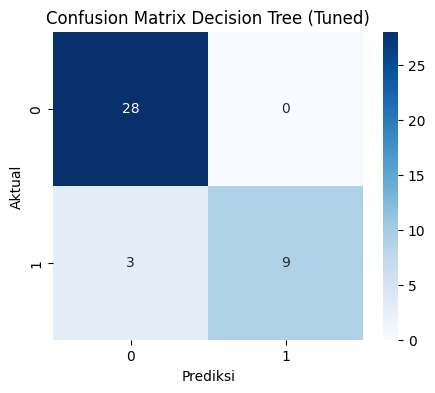

In [20]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Decision Tree (Tuned)')
plt.show()

In [21]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train_resampled, y_train_resampled)

y_pred_rf = rf_model.predict(X_test)

acc_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)

print('Akurasi Model Random Forest: ', acc_rf)
print('Confusion Matrix Random Forest: \n', cm_rf)
print('Classification Report Random Forest: \n', classification_report(y_test, y_pred_rf))

Akurasi Model Random Forest:  0.9
Confusion Matrix Random Forest: 
 [[27  1]
 [ 3  9]]
Classification Report Random Forest: 
               precision    recall  f1-score   support

       False       0.90      0.96      0.93        28
        True       0.90      0.75      0.82        12

    accuracy                           0.90        40
   macro avg       0.90      0.86      0.87        40
weighted avg       0.90      0.90      0.90        40



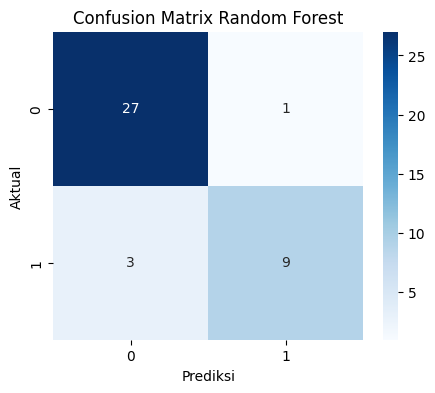

In [22]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Random Forest')
plt.show()

In [23]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_resampled, y_train_resampled)

y_pred_gb = gb_model.predict(X_test)

acc_gb = accuracy_score(y_test, y_pred_gb)
cm_gb = confusion_matrix(y_test, y_pred_gb)

print('Akurasi Model Gradient Boosting: ', acc_gb)
print('Confusion Matrix Gradient Boosting: \n', cm_gb)
print('Classification Report Gradient Boosting: \n', classification_report(y_test, y_pred_gb))

Akurasi Model Gradient Boosting:  0.9
Confusion Matrix Gradient Boosting: 
 [[27  1]
 [ 3  9]]
Classification Report Gradient Boosting: 
               precision    recall  f1-score   support

       False       0.90      0.96      0.93        28
        True       0.90      0.75      0.82        12

    accuracy                           0.90        40
   macro avg       0.90      0.86      0.87        40
weighted avg       0.90      0.90      0.90        40



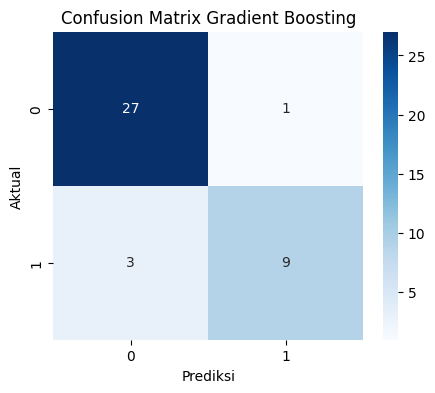

In [24]:
plt.figure(figsize=(5,4))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prediksi')
plt.ylabel('Aktual')
plt.title('Confusion Matrix Gradient Boosting')
plt.show()

**5. Visualisasikan pohon keputusan dengan parameter max_depth=3 dan bandingkan hasilnya.**

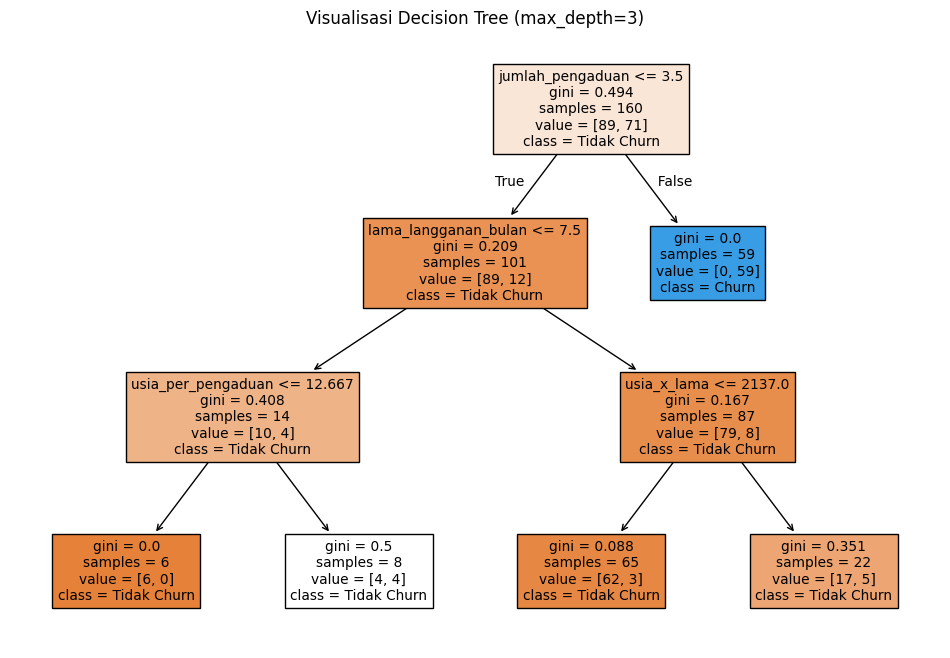

In [25]:
model_depth_3 = DecisionTreeClassifier(criterion='gini', max_depth=3, random_state=42)
model_depth_3.fit(X_train, y_train)

plt.figure(figsize=(12,8))
tree.plot_tree(model_depth_3, feature_names=X.columns, class_names=['Tidak Churn','Churn'], filled=True)
plt.title('Visualisasi Decision Tree (max_depth=3)')
plt.show()